In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [21]:
nfl_data = pd.read_csv("./NFL Play by Play 2009-2016 (v4).csv")
np.random.seed(0)

### Try to check first is there any `missing values`

In [22]:
# get the count of missing data points per coloumn
missing_values_count = nfl_data.isnull().sum()
missing_values_count[0:10]

Date                0
GameID              0
Drive               0
qtr                 0
down            54218
time              188
TimeUnder           0
TimeSecs          188
PlayTimeDiff      374
SideofField       450
dtype: int64

In [23]:
# how many total missing values do we have?
total_cells = np.prod(nfl_data.shape)
total_missing = missing_values_count.sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

27.652267428200588


### Removes any `row` having at least one NaN
here by doing this we removed all rows bcz in the csv every row contain NaN

In [24]:
nfl_data.dropna()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season


### Removes every `column` that has missing values

In [25]:
nfl_data.dropna(axis=1)

,Date,GameID,Drive,qtr,TimeUnder,ydstogo,ydsnet,PlayAttempted,Yards.Gained,sp,...,AwayTeam,Timeout_Indicator,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,ExPoint_Prob,TwoPoint_Prob,Season
0,2009-09-10,2009091000,1,1,15,0,0,1,39,0,...,TEN,0,3,3,3,3,3,0.000000,0.0,2009
1,2009-09-10,2009091000,1,1,15,10,5,1,5,0,...,TEN,0,3,3,3,3,3,0.000000,0.0,2009
2,2009-09-10,2009091000,1,1,15,5,2,1,-3,0,...,TEN,0,3,3,3,3,3,0.000000,0.0,2009
3,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.000000,0.0,2009
4,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.000000,0.0,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362442,2017-01-01,2017010102,20,4,1,10,35,1,35,1,...,GB,0,0,0,0,0,0,0.000000,0.0,2016
362443,2017-01-01,2017010102,20,4,1,0,35,1,0,1,...,GB,0,0,0,0,0,0,0.931115,0.0,2016
362444,2017-01-01,2017010102,21,4,1,0,0,1,0,0,...,GB,0,0,0,0,0,0,0.000000,0.0,2016
362445,2017-01-01,2017010102,21,4,1,10,-1,1,-1,0,...,GB,0,0,0,0,0,0,0.000000,0.0,2016


### Fill Missing Values

### Fill with `const`

In [26]:
nfl_data.fillna(0)

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,0.0,15:00,15,3600.0,0.0,TEN,...,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.000000,0.000000,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,0.000000,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.000000,0.000000,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362442,2017-01-01,2017010102,20,4,1.0,00:22,1,22.0,6.0,GB,...,0.000000,0.051901,0.948099,0.093435,0.906565,0.051901,0.041534,0.041534,0.000000,2016
362443,2017-01-01,2017010102,20,4,0.0,00:13,1,13.0,9.0,GB,...,0.000000,0.093435,0.906565,0.034069,0.965931,0.093435,-0.059366,0.000000,0.000000,2016
362444,2017-01-01,2017010102,21,4,0.0,00:13,1,13.0,0.0,DET,...,0.000000,0.034069,0.965931,0.035708,0.964292,0.965931,-0.001639,0.000000,0.000000,2016
362445,2017-01-01,2017010102,21,4,1.0,00:12,1,12.0,1.0,DET,...,0.000000,0.035708,0.964292,0.000000,1.000000,0.964292,0.035708,0.000000,0.000000,2016


### Fill with `Unknown`

In [27]:
nfl_data.fillna("Unknown")

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,Unknown,15:00,15,3600.0,0.0,TEN,...,Unknown,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,Unknown,Unknown,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,Unknown,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,Unknown,Unknown,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,Unknown,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,Unknown,Unknown,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362442,2017-01-01,2017010102,20,4,1.0,00:22,1,22.0,6.0,GB,...,0.0,0.051901,0.948099,0.093435,0.906565,0.051901,0.041534,0.041534,0.0,2016
362443,2017-01-01,2017010102,20,4,Unknown,00:13,1,13.0,9.0,GB,...,Unknown,0.093435,0.906565,0.034069,0.965931,0.093435,-0.059366,Unknown,Unknown,2016
362444,2017-01-01,2017010102,21,4,Unknown,00:13,1,13.0,0.0,DET,...,Unknown,0.034069,0.965931,0.035708,0.964292,0.965931,-0.001639,Unknown,Unknown,2016
362445,2017-01-01,2017010102,21,4,1.0,00:12,1,12.0,1.0,DET,...,Unknown,0.035708,0.964292,0.0,1.0,0.964292,0.035708,Unknown,Unknown,2016


In [28]:
# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

### Scaling - changuing the range of your data

### By scaling your variables, you can help compare different variables on equal footing

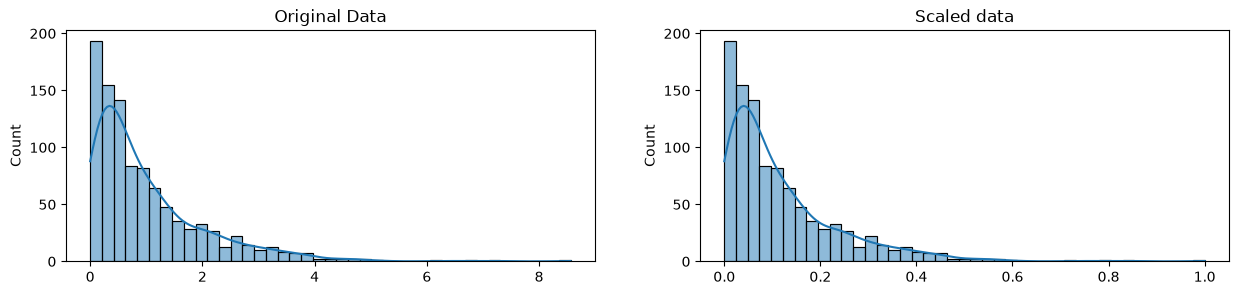

In [29]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Scaled data")
plt.show()

### Normalization

### Scaling just changes the range of your data. Normalization is a more radical transformation. The normal distribution is also known as the Gaussian distribution

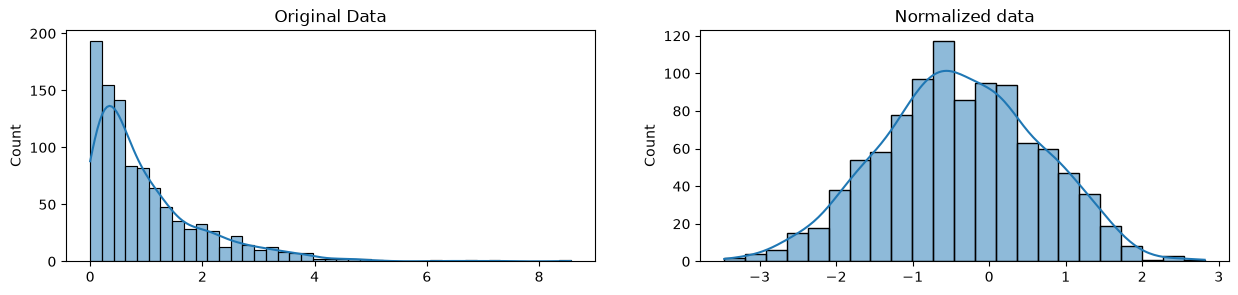

In [30]:
# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()

### Character Encodings

In [35]:
# start with a string
before = "This is the euro symbol: €"

# check to see what datatype it is
type(before)

str

In [36]:
# encode it to a different encoding, replacing characters that raise errors
after = before.encode("utf-8", errors="replace")

# check the type
type(after)

bytes

In [37]:
# convert it back to utf-8
print(after.decode("utf-8"))

This is the euro symbol: €


### Inconsistent Data Entry

In [42]:
professors = pd.read_csv("./pakistan_intellectual_capital.csv")
professors.head()

,Unnamed: 0,S#,Teacher Name,University Currently Teaching,Department,Province University Located,Designation,Terminal Degree,Graduated from,Country,Year,Area of Specialization/Research Interests,Other Information
0,2,3,Dr. Abdul Basit,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,Software Engineering & DBMS,NaN
1,4,5,Dr. Waheed Noor,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,DBMS,NaN
2,5,6,Dr. Junaid Baber,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"Information processing, Multimedia mining",NaN
3,6,7,Dr. Maheen Bakhtyar,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"NLP, Information Retrieval, Question Answering...",NaN
4,24,25,Samina Azim,Sardar Bahadur Khan Women's University,Computer Science,Balochistan,Lecturer,BS,Balochistan University of Information Technolo...,Pakistan,2005.0,VLSI Electronics DLD Database,NaN


In [44]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries = sorted(countries)
countries

[' Germany',
 ' New Zealand',
 ' Sweden',
 ' USA',
 'Australia',
 'Austria',
 'Canada',
 'China',
 'Finland',
 'France',
 'Greece',
 'HongKong',
 'Ireland',
 'Italy',
 'Japan',
 'Macau',
 'Malaysia',
 'Mauritius',
 'Netherland',
 'New Zealand',
 'Norway',
 'Pakistan',
 'Portugal',
 'Russian Federation',
 'Saudi Arabia',
 'Scotland',
 'Singapore',
 'South Korea',
 'SouthKorea',
 'Spain',
 'Sweden',
 'Thailand',
 'Turkey',
 'UK',
 'USA',
 'USofA',
 'Urbana',
 'germany']

### I can see some problems due to inconsistent data entry: `' Germany'`, and `'germany'`, for example, or `' New Zealand'` and `'New Zealand'`

### to solve make everything lower case useing `str.lower()` and for spaces use `str.strip()`

In [45]:
# convert to lower case
professors['Country'] = professors['Country'].str.lower()
# remove trailing white spaces
professors['Country'] = professors['Country'].str.strip()

In [46]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries = sorted(countries)
countries

['australia',
 'austria',
 'canada',
 'china',
 'finland',
 'france',
 'germany',
 'greece',
 'hongkong',
 'ireland',
 'italy',
 'japan',
 'macau',
 'malaysia',
 'mauritius',
 'netherland',
 'new zealand',
 'norway',
 'pakistan',
 'portugal',
 'russian federation',
 'saudi arabia',
 'scotland',
 'singapore',
 'south korea',
 'southkorea',
 'spain',
 'sweden',
 'thailand',
 'turkey',
 'uk',
 'urbana',
 'usa',
 'usofa']

### Fuzzy matching: The process of automatically finding text strings that are very similar to the target string. In general, a string is considered "closer" to another one the fewer characters you'd need to change if you were transforming one string into another. So "apple" and "snapple" are two changes away from each other (add "s" and "n") 

In [47]:
import fuzzywuzzy
from fuzzywuzzy import process

In [48]:
# get the top 10 closest matches to "south korea"
matches = fuzzywuzzy.process.extract("south korea", countries, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

# take a look at them
matches

[('south korea', 100),
 ('southkorea', 48),
 ('saudi arabia', 43),
 ('norway', 35),
 ('austria', 33),
 ('ireland', 33),
 ('pakistan', 32),
 ('portugal', 32),
 ('scotland', 32),
 ('australia', 30)]

### We can see that two of the items in the cities are very close to `south korea`: `south korea` and `southkorea`. Let's replace all rows in our `Country` column that have a ratio of > 47 with `south korea`

In [49]:
# function to replace rows in the provided column of the provided dataframe
# that match the provided string above the provided ratio with the provided string
def replace_matches_in_column(df, column, string_to_match, min_ratio = 47):
    # get a list of unique strings
    strings = df[column].unique()
    
    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings, 
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches 
    df.loc[rows_with_matches, column] = string_to_match
    
    # let us know the function's done
    print("All done!")

In [50]:
# use the function we just wrote to replace close matches to "south korea" with "south korea"
replace_matches_in_column(df=professors, column='Country', string_to_match="south korea")

All done!


In [52]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries = sorted(countries)
countries

['australia',
 'austria',
 'canada',
 'china',
 'finland',
 'france',
 'germany',
 'greece',
 'hongkong',
 'ireland',
 'italy',
 'japan',
 'macau',
 'malaysia',
 'mauritius',
 'netherland',
 'new zealand',
 'norway',
 'pakistan',
 'portugal',
 'russian federation',
 'saudi arabia',
 'scotland',
 'singapore',
 'south korea',
 'spain',
 'sweden',
 'thailand',
 'turkey',
 'uk',
 'urbana',
 'usa',
 'usofa']

----